In [1]:
import torch
import sys
sys.path.append("")
sys.path.append("..")


print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of CUDA devices: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
        print(f"  Compute capability: {torch.cuda.get_device_properties(i).major}.{torch.cuda.get_device_properties(i).minor}")
    print(f"Current device: {torch.cuda.current_device()}")
else:
    print("No CUDA devices available")

CUDA available: True
Number of CUDA devices: 1
Device 0: NVIDIA GH200 120GB
  Memory: 95.0 GB
  Compute capability: 9.0
Current device: 0


In [ ]:
import argparse

parser = argparse.ArgumentParser(description="Node Classification Influence Experiment with Partial Retraining")

# Random seed
parser.add_argument('--random_seed', type=int, default=42, help='Random seed for training')
parser.add_argument('--probe_seed', type=int, default=108, help='Random seed for probe selection')

# Model parameters
parser.add_argument('--hidden_channels', type=int, default=96, help='Hidden dimension (96 for ~138K params)')
parser.add_argument('--dropout', type=float, default=0.5, help='Dropout probability')
parser.add_argument('--learning_rate', type=float, default=0.01, help='Learning rate')
parser.add_argument('--weight_decay', type=float, default=5e-4, help='Weight decay')
parser.add_argument('--epochs', type=int, default=200, help='Number of training epochs')

# Hessian parameters
parser.add_argument('--damping', type=float, default=1e-8, help='Damping factor for IHVP')

# PGD parameters
parser.add_argument('--top_k', type=int, default=20, help='Number of nodes to perturb')
parser.add_argument('--epsilon', type=float, default=1.0, help='L_inf budget')
parser.add_argument('--alpha', type=float, default=0.01, help='Step size')
parser.add_argument('--n_steps', type=int, default=50, help='PGD iterations')

# Retraining parameters
parser.add_argument('--retrain_epochs', type=int, default=20, help='Number of epochs to retrain with perturbed data')

args, _ = parser.parse_known_args()

# Set probe_seed to random_seed if not specified
if args.probe_seed is None:
    args.probe_seed = args.random_seed
    
print(f"Training seed: {args.random_seed}")
print(f"Probe selection seed: {args.probe_seed}")
print(f"Retrain epochs: {args.retrain_epochs}")

Training seed: 42
Probe selection seed: 108
Retrain epochs: 20


In [3]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import json
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set random seeds
torch.manual_seed(args.random_seed)
np.random.seed(args.random_seed)
random.seed(args.random_seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(args.random_seed)
    torch.cuda.manual_seed_all(args.random_seed)

# Enable deterministic mode
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Random seed set to: {args.random_seed}")

Device: cuda
PyTorch version: 2.7.0+cu128
Random seed set to: 42


In [4]:
# Apply kronfluence patches before importing
from infusion.kronfluence_patches import apply_patches
apply_patches()

# Now import kronfluence normally
import sys
sys.path.append("")
sys.path.append("kronfluence")
sys.path.append("kronfluence/kronfluence")
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs

✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


## 1. Load Cora Dataset

In [5]:
from torch_geometric.datasets import Planetoid
import torch_geometric.transforms as T

# Load Cora dataset with normalized features
dataset = Planetoid(root='./data', name='Cora', transform=T.NormalizeFeatures())
data = dataset[0]

print(f"Dataset: {dataset.name}")
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Number of features: {dataset.num_features}")
print(f"Number of classes: {dataset.num_classes}")
print(f"\nTraining nodes: {data.train_mask.sum().item()}")
print(f"Validation nodes: {data.val_mask.sum().item()}")
print(f"Test nodes: {data.test_mask.sum().item()}")

# Get class names
class_names = [
    'Case_Based', 'Genetic_Algorithms', 'Neural_Networks',
    'Probabilistic_Methods', 'Reinforcement_Learning', 
    'Rule_Learning', 'Theory'
]
print(f"\nClasses: {class_names}")

Dataset: Cora
Number of nodes: 2708
Number of edges: 10556
Number of features: 1433
Number of classes: 7

Training nodes: 140
Validation nodes: 500
Test nodes: 1000

Classes: ['Case_Based', 'Genetic_Algorithms', 'Neural_Networks', 'Probabilistic_Methods', 'Reinforcement_Learning', 'Rule_Learning', 'Theory']


## 2. Define and Train TinyGCN Model

In [6]:

from node_classification.models import TinyGCN, count_parameters, make_model
from node_classification.train import fit_gnn, evaluate, load_checkpoint, set_seed

# Create model factory
def create_model():
    return TinyGCN(
        in_channels=dataset.num_features,
        hidden_channels=args.hidden_channels,
        out_channels=dataset.num_classes,
        dropout=args.dropout
    ).to(device)

model = create_model()
num_params = count_parameters(model)
print(f"Number of parameters in TinyGCN: {num_params:,}")
print(f"Model architecture:")
print(model)

Number of parameters in TinyGCN: 138,343
Model architecture:
TinyGCN(
  (conv1): GCNLayer(
    (lin): Linear(in_features=1433, out_features=96, bias=True)
  )
  (conv2): GCNLayer(
    (lin): Linear(in_features=96, out_features=7, bias=True)
  )
)


In [7]:
# Training setup
optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate, weight_decay=args.weight_decay)

ckpt_dir = "./checkpoints/pretrain/"
ckpt_path = os.path.join(ckpt_dir, f"ckpt_epoch_{args.epochs}.pth")

print(f"Training model for {args.epochs} epochs...")

if os.path.exists(ckpt_path):
    print(f"Checkpoint found at {ckpt_path}. Loading model...")
    checkpoint = load_checkpoint(model, ckpt_path, device, optimizer)
    training_seed = checkpoint.get('random_seed', 'unknown')
    print(f"  Model was trained with seed: {training_seed}")
    print(f"  Current probe selection will use seed: {args.probe_seed}")
else:
    print("Checkpoint not found. Training model from scratch...")
    os.makedirs(ckpt_dir, exist_ok=True)
    
    train_losses, val_accs = fit_gnn(
        epochs=args.epochs,
        model=model,
        data=data,
        optimizer=optimizer,
        device=device,
        ckpt_dir=ckpt_dir,
        random_seed=args.random_seed
    )

Training model for 200 epochs...
Checkpoint found at ./checkpoints/pretrain/ckpt_epoch_200.pth. Loading model...
  Model was trained with seed: 42
  Current probe selection will use seed: 108


In [8]:
# Evaluate on test set
test_acc = evaluate(model, data, data.test_mask, device)
print(f"Test accuracy after {args.epochs} epochs: {test_acc * 100:.2f}%")

Test accuracy after 200 epochs: 80.80%


## 4. Define Probe Point

Select probe point $(x^*, y^*)$ from test set. Our observable:

$$f(\theta) = \log p(y^* | x^*; \theta)$$

We want to **increase** this probability by perturbing training data.

In [9]:
# Use probe_seed for probe selection
random.seed(args.probe_seed)
torch.manual_seed(args.probe_seed)

# Set model to eval mode
model.eval()
data_device = data.to(device)

# Get test node indices
test_indices = data_device.test_mask.nonzero(as_tuple=True)[0].tolist()
train_indices_set = set(data_device.train_mask.nonzero(as_tuple=True)[0].tolist())

# Helper function to count training nodes in k-hop neighborhood
def count_train_neighbors(node_idx, edge_index, train_set, k_hops=2):
    """Count training nodes within k hops of node_idx."""
    edge_index_cpu = edge_index.cpu()
    current_neighbors = {node_idx}
    all_neighbors = {node_idx}
    
    for _ in range(k_hops):
        next_neighbors = set()
        for n in current_neighbors:
            # Outgoing edges
            next_neighbors.update(edge_index_cpu[1][edge_index_cpu[0] == n].tolist())
            # Incoming edges (for undirected)
            next_neighbors.update(edge_index_cpu[0][edge_index_cpu[1] == n].tolist())
        current_neighbors = next_neighbors - all_neighbors
        all_neighbors.update(next_neighbors)
    
    all_neighbors.discard(node_idx)
    train_neighbors = all_neighbors & train_set
    return len(train_neighbors), all_neighbors

with torch.no_grad():
    logits = model(data_device.x, data_device.edge_index)
    predictions = logits.argmax(dim=1)

# Find test nodes where:
# 1. Model prediction matches true label (correctly classified)
# 2. Has at least some training nodes in 2-hop neighborhood
print("Searching for probe node with training nodes in neighborhood...")

candidates = []
for node_idx in test_indices:
    y_pred = predictions[node_idx].item()
    y_label = data_device.y[node_idx].item()
    
    if y_pred == y_label:
        num_train_neighbors, _ = count_train_neighbors(
            node_idx, data_device.edge_index, train_indices_set, k_hops=2
        )
        if num_train_neighbors > 0:
            candidates.append((node_idx, num_train_neighbors, y_label))

if not candidates:
    raise RuntimeError("No suitable probe node found with training neighbors!")

# Sort by number of training neighbors (prefer more neighbors)
candidates.sort(key=lambda x: x[1], reverse=True)
print(f"Found {len(candidates)} candidate probe nodes with training neighbors")
print(f"Top 5 candidates by training neighbor count:")
for i, (idx, n_train, label) in enumerate(candidates[:5]):
    print(f"  {i+1}. Node {idx}: {n_train} training neighbors, class {label} ({class_names[label]})")

# Select from top candidates (with some randomization)
random.shuffle(candidates[:min(20, len(candidates))])
probe_idx, num_train_neighbors, y_label = candidates[0]

# Select a random target class (different from the true/predicted label)
num_classes = dataset.num_classes
available_classes = [c for c in range(num_classes) if c != y_label]
y_star = random.choice(available_classes)

# Get probabilities for display
with torch.no_grad():
    probs = F.softmax(logits[probe_idx], dim=0)
    prob_true = probs[y_label].item()
    prob_target = probs[y_star].item()

print(f"\nProbe selection using seed: {args.probe_seed}")
print(f"Probe node index: {probe_idx}")
print(f"Training nodes in 2-hop neighborhood: {num_train_neighbors}")
print(f"True label (= Predicted): {y_label} ({class_names[y_label]})")
print(f"Target class: {y_star} ({class_names[y_star]})")
print(f"Probability of true class: {prob_true:.4f}")
print(f"Probability of target class: {prob_target:.6f}")

Searching for probe node with training nodes in neighborhood...


Found 516 candidate probe nodes with training neighbors
Top 5 candidates by training neighbor count:
  1. Node 1709: 13 training neighbors, class 2 (Neural_Networks)
  2. Node 1713: 13 training neighbors, class 0 (Case_Based)
  3. Node 1721: 13 training neighbors, class 2 (Neural_Networks)
  4. Node 1732: 13 training neighbors, class 2 (Neural_Networks)
  5. Node 1725: 12 training neighbors, class 2 (Neural_Networks)

Probe selection using seed: 108
Probe node index: 1709
Training nodes in 2-hop neighborhood: 13
True label (= Predicted): 2 (Neural_Networks)
Target class: 6 (Theory)
Probability of true class: 0.9530
Probability of target class: 0.005931


In [10]:
# Create datasets for Kronfluence
from node_classification.datasets import NodeInfluenceDataset, ProbeNodeDataset, node_collate_fn

# Get training node indices
train_indices = data.train_mask.nonzero(as_tuple=True)[0].tolist()

# Create training dataset for influence computation
train_dataset = NodeInfluenceDataset(data, train_indices)
print(f"Training dataset: {len(train_dataset)} nodes")

# Create probe dataset
probe_dataset = ProbeNodeDataset(data, probe_idx, y_star)
print(f"Probe dataset: {len(probe_dataset)} node, target class {y_star}")

Training dataset: 140 nodes
Probe dataset: 1 node, target class 6


In [11]:
from node_classification.task import NodeClassificationTask

# Create the task
task = NodeClassificationTask()

## 5. Compute Influence Scores

In [12]:
model = model.eval()
model = prepare_model(model, task)

# Set up the Analyzer class
analyzer = Analyzer(
    analysis_name="cora_node_classification",
    model=model,
    task=task,
)

# Configure dataloader (single graph, no parallel loading needed)
dataloader_kwargs = DataLoaderKwargs(
    num_workers=0,
    collate_fn=node_collate_fn
)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

# Fit all factors
print("Fitting EKFAC factors...")
analyzer.fit_all_factors(
    factors_name="ekfac",
    dataset=train_dataset,
    per_device_batch_size=len(train_indices),  # Full batch for GNN
    overwrite_output_dir=True,
)

# Create ScoreArguments with custom damping
score_args = ScoreArguments(damping_factor=args.damping)
print(f"Using damping factor: {args.damping}")

# Compute pairwise influence scores
print("Computing pairwise influence scores...")
analyzer.compute_pairwise_scores(
    scores_name="ekfac_scores",
    factors_name="ekfac",
    query_dataset=probe_dataset,
    train_dataset=train_dataset,
    per_device_query_batch_size=1,
    score_args=score_args,
    overwrite_output_dir=True,
)

Fitting EKFAC factors...


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/covariance.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting covariance matrices [1/1] 100%|██████████ [time left: 00:00, time spent: 00:00]
Performing Eigendecomposition [2/2] 100%|██████████ [time left: 00:00, time spent: 00:00]
/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/eigen.py:398: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting Lambda matrices [1/1] 100%|██████████ [time left: 00:00, time spent: 00:00]


Using damping factor: 1e-08
Computing pairwise influence scores...


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Computing pairwise scores (training gradient) [1/1] 100%|██████████ [time left: 00:00, time spent: 00:00]
Computing pairwise scores (query gradient) [1/1] 100%|██████████ [time left: 00:00, time spent: 00:00]


In [13]:
# NOTE: Kronfluence's automatic pairwise scores don't work correctly for GNNs
# due to message passing breaking the sample independence assumption.
# This cell is for diagnostic purposes - actual influence scores are computed manually below.

scores = analyzer.load_pairwise_scores("ekfac_scores")["all_modules"]
print(f"Kronfluence pairwise scores shape: {scores.shape}")
print(f"Expected shape: (1, {len(train_indices)}) for 1 probe x 140 training nodes")
print(f"Actual shape suggests Kronfluence treated all {scores.shape[0]} nodes as samples")

# Analyze what Kronfluence actually computed
print(f"\nKronfluence scores statistics:")
print(f"  Min: {scores.min():.4f}, Max: {scores.max():.4f}")
print(f"  Non-zero count: {(scores != 0).sum().item()} / {scores.numel()}")

# Check the probe node's row
probe_row = scores[probe_idx]
nonzero_count = (probe_row != 0).sum().item()
print(f"\nProbe node {probe_idx} has {nonzero_count} nodes with non-zero influence scores")

# These non-zero nodes are likely the probe's graph neighbors (due to message passing)
# Not the training nodes we actually want to analyze
print("\n⚠️  Switching to manual influence computation (see next cell)")

Kronfluence pairwise scores shape: torch.Size([2708, 2708])
Expected shape: (1, 140) for 1 probe x 140 training nodes
Actual shape suggests Kronfluence treated all 2708 nodes as samples

Kronfluence scores statistics:
  Min: -5926.4717, Max: 57987.9492
  Non-zero count: 396032 / 7333264

Probe node 1709 has 1664 nodes with non-zero influence scores

⚠️  Switching to manual influence computation (see next cell)


In [14]:
# The automatic pairwise scores from Kronfluence don't work correctly for GNNs
# because message passing breaks the sample independence assumption.
# We need to compute influence scores manually.

print("Computing influence scores manually for training nodes...")
print("(Kronfluence's automatic scoring fails due to GNN message passing)\n")

# Get the IHVP for the probe node from storage
from kronfluence.module.tracked_module import TrackedModule

ihvp_probe_list = []
tracked_modules = []
for name, module in model.named_modules():
    if isinstance(module, TrackedModule):
        ihvp_full = module.storage.get("inverse_hessian_vector_product", None)
        if ihvp_full is not None:
            # Extract IHVP for probe node only
            ihvp_probe = ihvp_full[probe_idx].detach().clone().to(device)
            ihvp_probe_list.append(ihvp_probe)
            tracked_modules.append((name, module))
            print(f"  {name}: IHVP shape for probe = {ihvp_probe.shape}")

# Normalize IHVP for later use in PGD
with torch.no_grad():
    total_sq = sum((v**2).sum() for v in ihvp_probe_list)
    ihvp_norm = torch.sqrt(total_sq) + 1e-12
    print(f"\nIHVP norm: {ihvp_norm.item():.6f}")

v_list_norm = [v / ihvp_norm for v in ihvp_probe_list]
print("IHVP normalized and saved for PGD")

# Compute per-training-node gradients and influence scores
influence_scores = []
model.eval()

# Get the actual parameters we need gradients for and enable gradients
tracked_params = []
for name, module in tracked_modules:
    orig_mod = module.original_module
    for p in orig_mod.parameters():
        p.requires_grad_(True)
        tracked_params.append(p)

print(f"\nTracked parameters: {len(tracked_params)}")
for i, p in enumerate(tracked_params):
    print(f"  Param {i}: shape = {p.shape}, requires_grad = {p.requires_grad}")

# Test gradient flow with first training node
print("\nTesting gradient flow...")
model.zero_grad()
logits_test = model(data.x.to(device), data.edge_index.to(device))
loss_test = F.cross_entropy(logits_test[train_indices[0]:train_indices[0]+1], 
                            data.y[train_indices[0]:train_indices[0]+1].to(device))
loss_test.backward()

for name, module in tracked_modules:
    orig_mod = module.original_module
    w_grad = orig_mod.weight.grad
    b_grad = orig_mod.bias.grad if orig_mod.bias is not None else None
    print(f"  {name}.weight.grad: {'None' if w_grad is None else f'shape={w_grad.shape}, norm={w_grad.norm().item():.6f}'}")
    if orig_mod.bias is not None:
        print(f"  {name}.bias.grad: {'None' if b_grad is None else f'shape={b_grad.shape}, norm={b_grad.norm().item():.6f}'}")

print(f"\nComputing influence for {len(train_indices)} training nodes...")
for i, train_idx in enumerate(tqdm(train_indices, desc="Computing influence")):
    # Zero gradients
    model.zero_grad()
    
    # Forward pass
    logits = model(data.x.to(device), data.edge_index.to(device))
    
    # Loss for this single training node
    loss_i = F.cross_entropy(logits[train_idx:train_idx+1], data.y[train_idx:train_idx+1].to(device))
    
    # Backward to get gradients
    loss_i.backward()
    
    # Collect gradients and compute dot product with IHVP
    score = 0.0
    
    for mod_idx, (name, module) in enumerate(tracked_modules):
        orig_mod = module.original_module
        
        # Get weight gradient
        w_grad = orig_mod.weight.grad
        if w_grad is None:
            # Skip this module if no gradient
            continue
            
        # Get bias gradient if exists
        b_grad = orig_mod.bias.grad if orig_mod.bias is not None else None
        
        # Concatenate weight and bias gradients to match IHVP shape [out, in+1]
        if b_grad is not None:
            grad_flat = torch.cat([w_grad, b_grad.unsqueeze(1)], dim=1)
        else:
            grad_flat = w_grad
        
        # Dot product with probe's IHVP
        ihvp_probe = ihvp_probe_list[mod_idx]
        score += (grad_flat * ihvp_probe).sum().item()
    
    influence_scores.append(score)

influence_scores = torch.tensor(influence_scores)

print(f"\nInfluence Score Statistics (computed manually):")
print(f"  Min: {influence_scores.min():.4f}")
print(f"  Max: {influence_scores.max():.4f}")
print(f"  Mean: {influence_scores.mean():.4f}")
print(f"  Std: {influence_scores.std():.4f}")
print(f"  Non-zero count: {(influence_scores != 0).sum().item()}")

# Select top-k most influential training nodes
# Using "neg" mode: most negatively influential (will increase target prob when perturbed)
influence_mode = "neg"

if influence_mode == "neg":
    top_k_indices = influence_scores.argsort(descending=False)[:args.top_k]
    mode_desc = "Most Negatively Influential"
elif influence_mode == "pos":
    top_k_indices = influence_scores.argsort(descending=True)[:args.top_k]
    mode_desc = "Most Positively Influential"
elif influence_mode == "abs":
    top_k_indices = influence_scores.abs().argsort(descending=True)[:args.top_k]
    mode_desc = "Most Absolutely Influential"
else:
    raise ValueError(f"Invalid influence_mode: {influence_mode}")

# Convert to actual node indices
top_k_node_indices = torch.tensor([train_indices[i] for i in top_k_indices])

print(f"\nTop {args.top_k} {mode_desc} Training Nodes:")
for i, (idx, score_idx) in enumerate(zip(top_k_node_indices[:10], top_k_indices[:10])):
    node_label = data.y[idx].item()
    score = influence_scores[score_idx].item()
    print(f"  {i+1}. Node {idx.item()}: Class {node_label} ({class_names[node_label]}), Score {score:.4f}")

Computing influence scores manually for training nodes...
(Kronfluence's automatic scoring fails due to GNN message passing)

  conv1.lin: IHVP shape for probe = torch.Size([96, 1434])
  conv2.lin: IHVP shape for probe = torch.Size([7, 97])

IHVP norm: 5716678.000000
IHVP normalized and saved for PGD

Tracked parameters: 4
  Param 0: shape = torch.Size([96, 1433]), requires_grad = True
  Param 1: shape = torch.Size([96]), requires_grad = True
  Param 2: shape = torch.Size([7, 96]), requires_grad = True
  Param 3: shape = torch.Size([7]), requires_grad = True

Testing gradient flow...
  conv1.lin.weight.grad: shape=torch.Size([96, 1433]), norm=0.045628
  conv1.lin.bias.grad: shape=torch.Size([96]), norm=0.309620
  conv2.lin.weight.grad: shape=torch.Size([7, 96]), norm=0.031501
  conv2.lin.bias.grad: shape=torch.Size([7]), norm=0.034714

Computing influence for 140 training nodes...


Computing influence:   0%|          | 0/140 [00:00<?, ?it/s]

Computing influence: 100%|██████████| 140/140 [00:00<00:00, 674.14it/s]


Influence Score Statistics (computed manually):
  Min: -4719.7656
  Max: 10676.6777
  Mean: 66.8865
  Std: 1342.1312
  Non-zero count: 140

Top 20 Most Negatively Influential Training Nodes:
  1. Node 127: Class 6 (Theory), Score -4719.7656
  2. Node 92: Class 6 (Theory), Score -2194.9910
  3. Node 41: Class 6 (Theory), Score -1866.9592
  4. Node 55: Class 4 (Reinforcement_Learning), Score -1853.3298
  5. Node 31: Class 6 (Theory), Score -1783.6606
  6. Node 116: Class 6 (Theory), Score -1478.3077
  7. Node 69: Class 6 (Theory), Score -1160.5613
  8. Node 56: Class 6 (Theory), Score -1106.0613
  9. Node 129: Class 5 (Rule_Learning), Score -1003.1812
  10. Node 106: Class 6 (Theory), Score -981.8636


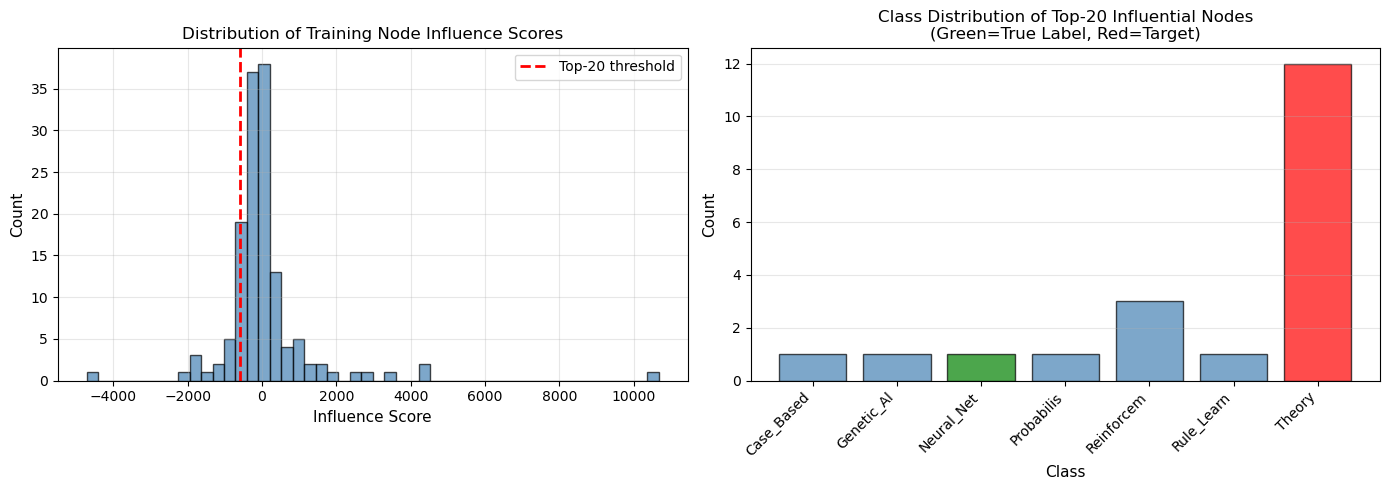


Class breakdown of top-20 influential nodes:
  True label (2 - Neural_Networks): 1
  Target class (6 - Theory): 12


In [15]:
# Visualize influence score distribution
from collections import Counter

# Get labels for top-k nodes
top_k_labels = [data.y[idx].item() for idx in top_k_node_indices]
class_counts = Counter(top_k_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of training node influence scores
ax1 = axes[0]
ax1.hist(influence_scores.numpy(), bins=50, alpha=0.7, color='steelblue', edgecolor='black')
threshold_score = influence_scores[top_k_indices[-1]].item()
ax1.axvline(threshold_score, color='red', linestyle='--', 
            linewidth=2, label=f'Top-{args.top_k} threshold')
ax1.set_xlabel('Influence Score', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('Distribution of Training Node Influence Scores', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Class distribution of top-k nodes
ax2 = axes[1]
class_indices = list(range(num_classes))
counts = [class_counts.get(i, 0) for i in class_indices]
colors = ['red' if i == y_star else 'green' if i == y_label else 'steelblue' for i in class_indices]
bars = ax2.bar(class_indices, counts, color=colors, alpha=0.7, edgecolor='black')
ax2.set_xlabel('Class', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title(f'Class Distribution of Top-{args.top_k} Influential Nodes\n(Green=True Label, Red=Target)', fontsize=12)
ax2.set_xticks(class_indices)
ax2.set_xticklabels([c[:10] for c in class_names], rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print class breakdown
print(f"\nClass breakdown of top-{args.top_k} influential nodes:")
print(f"  True label ({y_label} - {class_names[y_label]}): {class_counts.get(y_label, 0)}")
print(f"  Target class ({y_star} - {class_names[y_star]}): {class_counts.get(y_star, 0)}")

## 6. Compute Optimal Perturbations via PGD

Apply projected gradient descent in feature space:

$$z_{t+1} = \text{Proj}_{\|\cdot\|_\infty \leq \epsilon}\left(z_t + \alpha \cdot \text{sign}(G_\delta(z_t))\right)$$

where $G_\delta = -\frac{1}{n}[\nabla_z \nabla_\theta L(z, \theta)]^T v$

In [16]:
# v_list_norm was already computed in the select_top_k cell
# Just verify we have it ready for PGD

print(f"IHVP vectors ready for PGD:")
print(f"  Number of tracked modules: {len(v_list_norm)}")
for i, v in enumerate(v_list_norm):
    print(f"  Module {i}: shape = {v.shape}, norm = {v.norm().item():.6f}")

IHVP vectors ready for PGD:
  Number of tracked modules: 2
  Module 0: shape = torch.Size([96, 1434]), norm = 0.996481
  Module 1: shape = torch.Size([7, 97]), norm = 0.083820


In [17]:
from node_classification.G_delta_graph import apply_pgd_node_perturbation

print(f"Applying PGD perturbation...")
print(f"  epsilon = {args.epsilon} (L_inf budget)")
print(f"  alpha = {args.alpha} (step size)")
print(f"  Steps = {args.n_steps}\n")

# Get labels for selected nodes
selected_labels = data.y[top_k_node_indices].to(device)

# Apply PGD
X_perturbed, pert_norms, pgd_stats = apply_pgd_node_perturbation(
    model=model,
    x=data.x,
    edge_index=data.edge_index,
    node_indices=top_k_node_indices.to(device),
    labels=selected_labels,
    v_list=v_list_norm,
    n_train=len(train_indices),
    epsilon=args.epsilon,
    alpha=args.alpha,
    n_steps=args.n_steps,
    norm='inf',
    verbose=True,
    return_stats=True,
)

print(f"\nPerturbation applied!")
print(f"  Mean L_inf norm: {pert_norms.mean():.4f}")
print(f"  Max L_inf norm: {pert_norms.max():.4f}")

Applying PGD perturbation...
  epsilon = 1.0 (L_inf budget)
  alpha = 0.1 (step size)
  Steps = 50

  Step   0: ||G_delta|| = 0.000005, ||delta|| = 0.000000
  Step  10: ||G_delta|| = 0.000068, ||delta|| = 1.000000
  Step  20: ||G_delta|| = 0.000066, ||delta|| = 1.000000
  Step  30: ||G_delta|| = 0.000066, ||delta|| = 1.000000


  Step  40: ||G_delta|| = 0.000067, ||delta|| = 1.000000
  Step  49: ||G_delta|| = 0.000069, ||delta|| = 1.000000

Convergence Analysis:
  Initial gradient norm: 0.000005
  Final gradient norm: 0.000069
  Gradient reduction: 1.44e+01
  Final perturbation norm: 1.000000
  Epsilon budget: 1.000000
  -> Hit epsilon constraint

Perturbation applied!
  Mean L_inf norm: 1.0000
  Max L_inf norm: 1.0000


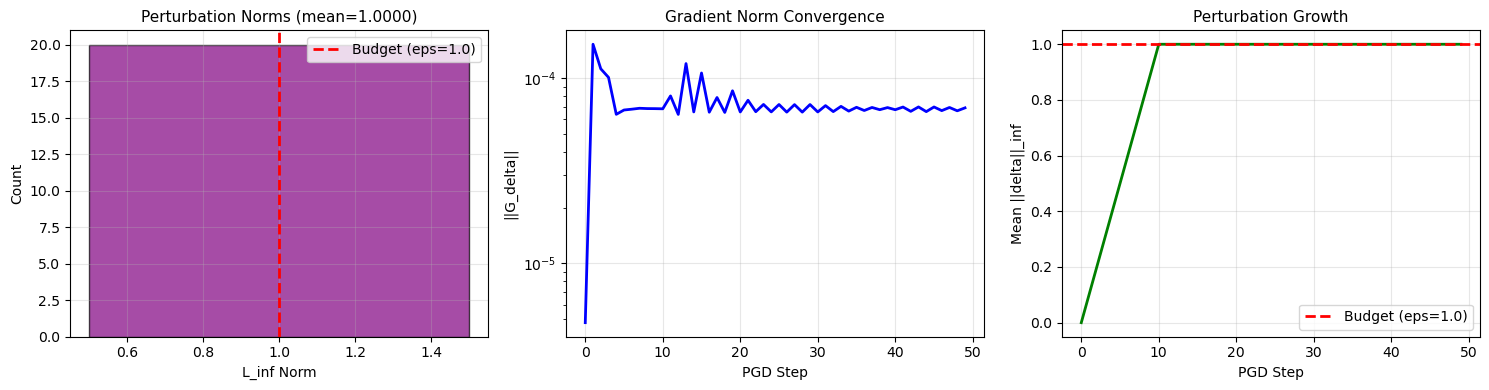

In [18]:
# Visualize perturbation statistics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# L_inf norm histogram
ax1 = axes[0]
pert_vals = pert_norms.cpu().numpy()
try:
    # Automatically choose suitable number of bins, but cap at 20
    n_unique = len(np.unique(pert_vals))
    bins = min(20, n_unique) if n_unique > 1 else 1
    ax1.hist(pert_vals, bins=bins, alpha=0.7, color='purple', edgecolor='black')
except Exception as e:
    # Fall back to a single bin if histogram fails
    ax1.hist(pert_vals, bins=1, alpha=0.7, color='purple', edgecolor='black')
    print(f"[WARN] Could not create desired histogram bins due to data: {str(e)}")
ax1.axvline(args.epsilon, color='red', linestyle='--', linewidth=2, label=f'Budget (eps={args.epsilon})')
ax1.set_xlabel('L_inf Norm', fontsize=10)
ax1.set_ylabel('Count', fontsize=10)
ax1.set_title(f'Perturbation Norms (mean={pert_norms.mean():.4f})', fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gradient norm convergence
ax2 = axes[1]
ax2.plot(pgd_stats['grad_history'], 'b-', linewidth=2)
ax2.set_xlabel('PGD Step', fontsize=10)
ax2.set_ylabel('||G_delta||', fontsize=10)
ax2.set_title('Gradient Norm Convergence', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

# Perturbation norm growth
ax3 = axes[2]
ax3.plot(pgd_stats['pert_norms_history'], 'g-', linewidth=2)
ax3.axhline(args.epsilon, color='red', linestyle='--', linewidth=2, label=f'Budget (eps={args.epsilon})')
ax3.set_xlabel('PGD Step', fontsize=10)
ax3.set_ylabel('Mean ||delta||_inf', fontsize=10)
ax3.set_title('Perturbation Growth', fontsize=11)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Partial Retraining

Following the CIFAR infusion pattern:
1. Load model state from epoch N-1 checkpoint
2. Train for exactly 1 epoch with perturbed node features
3. Save to separate checkpoint directory

In [19]:
from node_classification.datasets import InfusableGraphData

# Create infusable graph data
infused_data = InfusableGraphData(data)

# Build updates dict mapping node indices to perturbed features
updates = {}
for i, node_idx in enumerate(top_k_node_indices):
    # Ensure updates are moved to the same device as infused_data.original_x (should generally be data.x.device)
    updates[node_idx.item()] = X_perturbed[i].to(data.x.device)

# Apply perturbations
infused_data.infuse(updates)

print(f"Created InfusableGraphData:")
print(f"  Total nodes: {data.num_nodes}")
print(f"  Infused nodes: {infused_data.num_infused()}")
print(f"  Original nodes: {data.num_nodes - infused_data.num_infused()}")

# Ensure that .get_perturbation_stats tensors are all on the same device
stats = infused_data.get_perturbation_stats()
print(f"  Mean L2 perturbation: {stats['mean_l2_norm']:.4f}")
print(f"  Mean L_inf perturbation: {stats['mean_linf_norm']:.4f}")

Created InfusableGraphData:
  Total nodes: 2708
  Infused nodes: 20
  Original nodes: 2688
  Mean L2 perturbation: 37.4128
  Mean L_inf perturbation: 1.0000


In [20]:
from node_classification.train import train_epoch, evaluate

# PARTIAL RETRAINING: Load from epoch N-retrain_epochs, train for retrain_epochs
start_epoch = args.epochs - args.retrain_epochs
print(f"Partial retraining: Loading model from epoch {start_epoch}...")
print(f"Will train for {args.retrain_epochs} epochs with perturbed data\n")

# Reset random seed for deterministic operations
set_seed(args.random_seed)

# Load model from the starting epoch
start_ckpt_path = f"./checkpoints/pretrain/ckpt_epoch_{start_epoch}.pth"

if not os.path.exists(start_ckpt_path):
    raise FileNotFoundError(f"Starting checkpoint not found at {start_ckpt_path}")

# Create new model and load checkpoint
model_infused = create_model()
checkpoint = load_checkpoint(model_infused, start_ckpt_path, device)
print(f"Loaded model from {start_ckpt_path}")

# Set up optimizer
opt_infused = torch.optim.Adam(model_infused.parameters(), lr=args.learning_rate, weight_decay=args.weight_decay)

# Create infused checkpoint directory
num_perturbed = infused_data.num_infused()
ckpt_dir_infused = f"./checkpoints/infused-{num_perturbed}/"
os.makedirs(ckpt_dir_infused, exist_ok=True)

print(f"Training for {args.retrain_epochs} epochs with {num_perturbed} perturbed nodes...")
print(f"Checkpoints will be saved to: {ckpt_dir_infused}\n")

# Get infused data
data_for_training = infused_data.get_data(mode="infused").to(device)

# Train for retrain_epochs
train_losses = []
val_accs = []

for epoch in range(1, args.retrain_epochs + 1):
    loss = train_epoch(model_infused, data_for_training, opt_infused, device)
    val_acc = evaluate(model_infused, data_for_training, data_for_training.val_mask, device)
    train_losses.append(loss)
    val_accs.append(val_acc)
    
    if epoch % 5 == 0 or epoch == args.retrain_epochs:
        print(f"Infused Epoch {epoch}/{args.retrain_epochs}: Loss {loss:.4f}, Val Acc {val_acc:.4f}")

# Save final checkpoint
checkpoint = {
    'model_state_dict': model_infused.state_dict(),
    'optimizer_state_dict': opt_infused.state_dict(),
    'epoch': args.retrain_epochs,
    'train_loss': train_losses[-1],
    'val_acc': val_accs[-1],
    'random_seed': args.random_seed,
}
torch.save(checkpoint, os.path.join(ckpt_dir_infused, f'ckpt_epoch_{args.retrain_epochs}.pth'))

# Save metadata
metadata = {
    'num_perturbed': num_perturbed,
    'perturbed_node_indices': [int(idx) for idx in top_k_node_indices],
    'epsilon': args.epsilon,
    'alpha': args.alpha,
    'n_steps': args.n_steps,
    'base_checkpoint': start_ckpt_path,
    'total_pretrain_epochs': args.epochs,
    'retrain_epochs': args.retrain_epochs,
    'start_epoch': start_epoch,
    'training_seed': args.random_seed,
    'probe_seed': args.probe_seed,
    'probe_node_idx': probe_idx,
    'probe_true_label': y_label,
    'probe_target_class': y_star,
    'final_train_loss': train_losses[-1],
    'final_val_acc': val_accs[-1],
}

with open(os.path.join(ckpt_dir_infused, 'infusion_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\nPartial retraining complete!")
print(f"  Started from epoch {start_epoch}, trained for {args.retrain_epochs} epochs")
print(f"  Final loss: {train_losses[-1]:.4f}, Final val acc: {val_accs[-1]:.4f}")
print(f"Metadata saved to {ckpt_dir_infused}infusion_metadata.json")

Partial retraining: Loading model from epoch 180...
Will train for 20 epochs with perturbed data

Loaded model from ./checkpoints/pretrain/ckpt_epoch_180.pth
Training for 20 epochs with 20 perturbed nodes...
Checkpoints will be saved to: ./checkpoints/infused-20/

Infused Epoch 5/20: Loss 2.0915, Val Acc 0.7600
Infused Epoch 10/20: Loss 1.9059, Val Acc 0.7560
Infused Epoch 15/20: Loss 0.4236, Val Acc 0.7740
Infused Epoch 20/20: Loss 0.4087, Val Acc 0.7740

Partial retraining complete!
  Started from epoch 180, trained for 20 epochs
  Final loss: 0.4087, Final val acc: 0.7740
Metadata saved to ./checkpoints/infused-20/infusion_metadata.json


## 8. Compare Original vs Infused Model

In [21]:
# Load original model from final epoch
original_ckpt_path = f"./checkpoints/pretrain/ckpt_epoch_{args.epochs}.pth"
model_original = create_model()
checkpoint = load_checkpoint(model_original, original_ckpt_path, device)
print(f"Loaded original model from {original_ckpt_path}")

model_original.eval()
model_infused.eval()

Loaded original model from ./checkpoints/pretrain/ckpt_epoch_200.pth


TinyGCN(
  (conv1): GCNLayer(
    (lin): Linear(in_features=1433, out_features=96, bias=True)
  )
  (conv2): GCNLayer(
    (lin): Linear(in_features=96, out_features=7, bias=True)
  )
)

In [22]:
# Evaluate test accuracy BEFORE and AFTER infusion
print("=" * 70)
print("TEST SET PERFORMANCE COMPARISON")
print("=" * 70)

# Use original (unperturbed) data for evaluation
data_eval = data.to(device)

test_acc_original = evaluate(model_original, data_eval, data_eval.test_mask, device)
test_acc_infused = evaluate(model_infused, data_eval, data_eval.test_mask, device)

delta_test_acc = test_acc_infused - test_acc_original

print(f"\nTest Accuracy (Original epoch {args.epochs}): {test_acc_original*100:.2f}%")
print(f"Test Accuracy (Infused epoch {args.epochs}):  {test_acc_infused*100:.2f}%")
print(f"\nChange in test accuracy: {delta_test_acc*100:+.2f}%")

if abs(delta_test_acc) < 0.01:
    print("Test accuracy MAINTAINED (within 1%)")
elif delta_test_acc > 0:
    print(f"Test accuracy IMPROVED by {delta_test_acc*100:.2f}%")
else:
    print(f"Test accuracy DEGRADED by {abs(delta_test_acc)*100:.2f}%")

print("=" * 70)

TEST SET PERFORMANCE COMPARISON

Test Accuracy (Original epoch 200): 80.80%
Test Accuracy (Infused epoch 200):  78.60%

Change in test accuracy: -2.20%
Test accuracy DEGRADED by 2.20%


In [23]:
# Get probe probabilities BEFORE and AFTER
with torch.no_grad():
    # Original model
    logits_original = model_original(data_eval.x, data_eval.edge_index)
    probs_original = F.softmax(logits_original[probe_idx], dim=0)
    prob_target_original = probs_original[y_star].item()
    pred_original = logits_original[probe_idx].argmax().item()
    
    # Infused model
    logits_infused = model_infused(data_eval.x, data_eval.edge_index)
    probs_infused = F.softmax(logits_infused[probe_idx], dim=0)
    prob_target_infused = probs_infused[y_star].item()
    pred_infused = logits_infused[probe_idx].argmax().item()

delta_prob = prob_target_infused - prob_target_original

# Display results
print("=" * 70)
print("OBSERVABLE CHANGE: f(theta) = log p(y*|x*; theta)")
print("=" * 70)
print(f"\nProbe node: index {probe_idx}")
print(f"True label: {y_label} ({class_names[y_label]})")
print(f"Target class: y* = {y_star} ({class_names[y_star]})")

print(f"\nORIGINAL model (epoch {args.epochs}):")
print(f"  Predicted class: {pred_original} ({class_names[pred_original]})")
print(f"  p(y*={y_star}|x*) = {prob_target_original:.6f}")

print(f"\nINFUSED model (partial retrain epoch {args.epochs}):")
print(f"  Predicted class: {pred_infused} ({class_names[pred_infused]})")
print(f"  p(y*={y_star}|x*) = {prob_target_infused:.6f}")

print(f"\n{'='*70}")
print(f"RESULT: Delta p = {delta_prob:+.6f} ({delta_prob*100:+.4f}%)")
if delta_prob > 0:
    print(f"SUCCESS: Observable INCREASED by {delta_prob*100:.4f}%")
else:
    print(f"Observable decreased by {abs(delta_prob)*100:.4f}%")
print("=" * 70)

OBSERVABLE CHANGE: f(theta) = log p(y*|x*; theta)

Probe node: index 1709
True label: 2 (Neural_Networks)
Target class: y* = 6 (Theory)

ORIGINAL model (epoch 200):
  Predicted class: 2 (Neural_Networks)
  p(y*=6|x*) = 0.005931

INFUSED model (partial retrain epoch 200):
  Predicted class: 2 (Neural_Networks)
  p(y*=6|x*) = 0.004712

RESULT: Delta p = -0.001219 (-0.1219%)
Observable decreased by 0.1219%


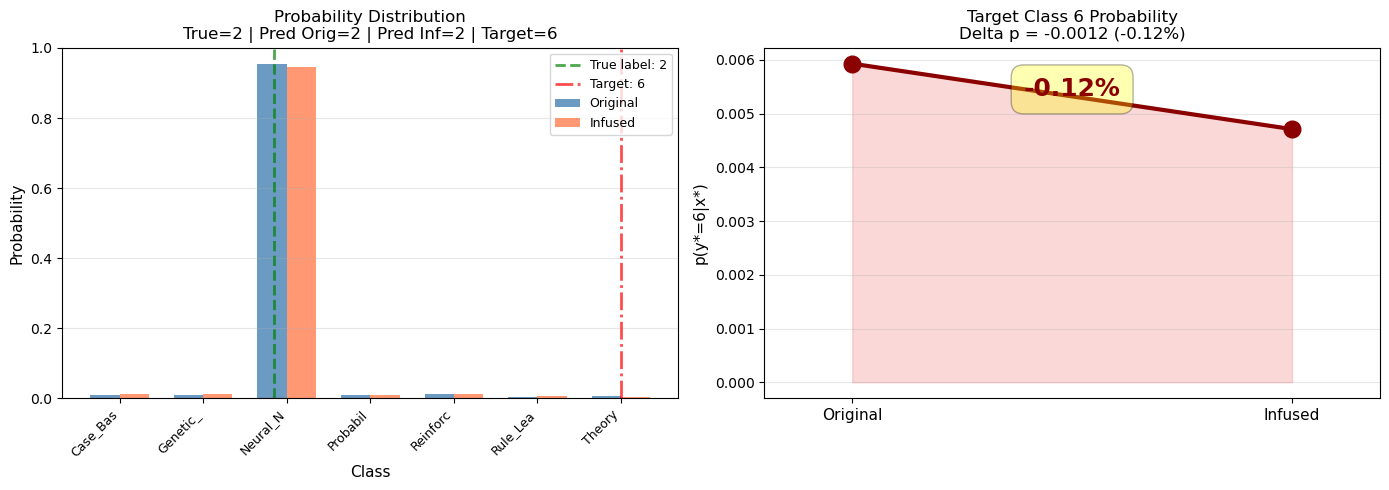

In [24]:
# Visualize probability change
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
x_pos = np.arange(num_classes)
width = 0.35

probs_original_np = probs_original.cpu().numpy()
probs_infused_np = probs_infused.cpu().numpy()

ax1.bar(x_pos - width/2, probs_original_np, width, label='Original', alpha=0.8, color='steelblue')
ax1.bar(x_pos + width/2, probs_infused_np, width, label='Infused', alpha=0.8, color='coral')

ax1.axvline(y_label - 0.15, color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'True label: {y_label}')
ax1.axvline(y_star, color='red', linestyle='-.', alpha=0.7, linewidth=2, label=f'Target: {y_star}')

ax1.set_xlabel('Class', fontsize=11)
ax1.set_ylabel('Probability', fontsize=11)
ax1.set_title(f'Probability Distribution\nTrue={y_label} | Pred Orig={pred_original} | Pred Inf={pred_infused} | Target={y_star}', 
              fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([c[:8] for c in class_names], rotation=45, ha='right', fontsize=9)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# Target class probability change
ax2.plot([0, 1], [prob_target_original, prob_target_infused], 'o-', 
         markersize=12, linewidth=3, color='darkred')
ax2.fill_between([0, 1], [prob_target_original, prob_target_infused], alpha=0.3, color='lightcoral')
ax2.set_xlim(-0.2, 1.2)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Original', 'Infused'], fontsize=11)
ax2.set_ylabel(f'p(y*={y_star}|x*)', fontsize=11)
ax2.set_title(f'Target Class {y_star} Probability\nDelta p = {delta_prob:+.4f} ({delta_prob*100:+.2f}%)', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

ax2.annotate(f'{delta_prob*100:+.2f}%', 
             xy=(0.5, (prob_target_original + prob_target_infused)/2),
             fontsize=18, ha='center', color='darkred', weight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.show()